In [1]:
!bash -lc 'module load Miniforge3/24.1.2-0 && source $EBROOTMINIFORGE3/bin/activate && conda activate hycom-cice'
import xarray as xr

The following modules were not unloaded:
  (Use "module --force purge" to unload all):

  1) StdEnv


In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import TwoSlopeNorm

def ArcticMap():

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.NorthPolarStereo(central_longitude=0.0)},
    )

    ax.set_extent([-180, 180, 48, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor=cfeature.COLORS["land"], edgecolor="grey", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", linewidth=0.4, zorder=3)
    ax.gridlines()
      
    return fig, ax
    
def pcolormesh_curvilinear(lon, lat, data, ax=None, **kwargs):

    proj = ax.projection
    pxy = proj.transform_points(ccrs.PlateCarree(), lon, lat)
    px, py = pxy[:, :, 0], pxy[:, :, 1]
    invalid = ~np.isfinite(px) | ~np.isfinite(py)
    px = np.where(invalid, 0.0, px)
    py = np.where(invalid, 0.0, py)
    data = np.where(invalid, np.nan, data)
    return ax.pcolormesh(px, py, data, **kwargs)


In [13]:
from glob import glob
import cftime

varlist = ["uvellvl","vvellvl","ubaro","vbaro"]

NORCPM_PATH = "/cluster/projects/nn9481k/arnaud/Script-tools/SEACLIM/norcpm_clim/"
#REFRUN_PATH = "/cluster/projects/nn9481k/arnaud/Script-tools/SEACLIM/ref_clim/"
REFRUN_PATH = "/cluster/work/users/arnelt/clim_ave/"
REFRUN_PATH_BARO = "/cluster/projects/nn9481k/arnaud/Script-tools/SEACLIM/ref_clim/"

#filelist_norcpm = sorted(glob(NORCPM_PATH + "noresm2-mm-seaclim_hindcast.blom.hmphy20n.clim.1993-2024.startmonth11.leadmonth1-64.mem1-10.nc"))
filelist_norcpm = sorted(glob(NORCPM_PATH + "noresm2-mm-seaclim_hindcast.blom*"))
filelist_refrun = sorted(glob(REFRUN_PATH + "clim_1993_2024_*"))
filelist_refrun_baro = sorted(glob(REFRUN_PATH_BARO + "clim_1993_2024_*"))

common_time = [
    cftime.DatetimeNoLeap(1999, m, 15)
    for m in range(11, 13)
] + [
    cftime.DatetimeNoLeap(y, m, 15)
    for y in range(2000,2005)
    for m in range(1, 13)
] + [
    cftime.DatetimeNoLeap(2005, m, 15)
    for m in range(1, 3)
]

norcpm_datasets = []

for f in filelist_norcpm:
    ds_temp = xr.open_dataset(f, use_cftime=True)

    if "depth_bnds" in ds_temp.variables:
        ds_temp = ds_temp.drop_vars("depth_bnds")
    if ds_temp.attrs.get("bounds") is not None:
        ds_temp["depth"].attrs.pop("bounds")

    # Replace the existing time coordinate
    ds_temp = ds_temp.assign_coords(time=common_time)

    norcpm_datasets.append(ds_temp)

ds_norcpm = xr.merge(norcpm_datasets)
ds_temp.close()

ds_norcpm = ds_norcpm.drop_vars(["plon", "plat"])
ds_norcpm = ds_norcpm[varlist]

ds_refrun_temp = xr.open_mfdataset(filelist_refrun, combine="by_coords", use_cftime=True, chunks={"time": 1})
ds_refrun_baro = xr.open_mfdataset(filelist_refrun_baro, combine="by_coords", use_cftime=True, chunks={"time": 1})
print(ds_refrun_temp)
ds_refrun_temp = ds_refrun_temp.set_coords(["latitude", "longitude"])
ds_refrun_baro = ds_refrun_baro.set_coords(["latitude", "longitude"])
ds_refrun = xr.merge([ds_refrun_temp, ds_refrun_baro])

ds_refrun = xr.concat([ds_refrun] * 7, dim="time")
ds_refrun = ds_refrun.isel(time=slice(10, 74))

ds_refrun = ds_refrun.assign_coords(time=common_time)

rename_dict = {
    "uo":"uvellvl",
    "vo":"vvellvl"
}
ds_refrun = ds_refrun.rename(rename_dict)

"""lon2d = ds_refrun.longitude.isel(time=0).drop_vars("time")
lat2d = ds_refrun.latitude.isel(time=0).drop_vars("time")

ds_refrun = (
    ds_refrun
    .drop_vars(["longitude", "latitude"])
    .assign_coords(
        lon=((lon2d + 360) % 360),
        lat=lat2d
    )
)"""

ds_refrun = ds_refrun[varlist]

/tmp/ipykernel_1345377/850198987.py:31: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds_temp = xr.open_dataset(f, use_cftime=True)
/cluster/projects/nn9481k/conda/arnelt/hycom-cice/lib/python3.11/site-packages/xarray/coding/times.py:383: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/tmp/ipykernel_1345377/850198987.py:31: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds_temp = xr.open

<xarray.Dataset> Size: 5GB
Dimensions:      (time: 12, y: 380, x: 400, depth: 40)
Coordinates:
  * time         (time) object 96B 2008-07-17 12:00:00 ... 2009-06-16 18:00:00
  * y            (y) float32 2kB 1.0 2.0 3.0 4.0 5.0 ... 377.0 378.0 379.0 380.0
  * x            (x) float32 2kB 1.0 2.0 3.0 4.0 5.0 ... 397.0 398.0 399.0 400.0
  * depth        (depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 3.5e+03 4e+03
Data variables: (12/27)
    longitude    (time, y, x) float32 7MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    latitude     (time, y, x) float32 7MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    model_depth  (time, y, x) float32 7MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    chl          (time, depth, y, x) float32 292MB dask.array<chunksize=(1, 20, 190, 200), meta=np.ndarray>
    no3          (time, depth, y, x) float32 292MB dask.array<chunksize=(1, 20, 190, 200), meta=np.ndarray>
    po4          (time, depth, y, x) float32 292MB dask.array

In [11]:
norcpm_grid = xr.open_dataset("norcpm_clim/NorESM2-MM_ocean_grid.nc")
ref_grid = xr.open_dataset("ref_clim/cice_grid.nc")

In [14]:
ref_grid

<xarray.Dataset> Size: 9MB
Dimensions:  (y: 380, x: 400)
Dimensions without coordinates: y, x
Data variables:
    ulat     (y, x) float64 1MB ...
    ulon     (y, x) float64 1MB ...
    hte      (y, x) float64 1MB ...
    htn      (y, x) float64 1MB ...
    hus      (y, x) float64 1MB ...
    huw      (y, x) float64 1MB ...
    angle    (y, x) float64 1MB ...

In [15]:
ds_refrun["speed"] = (ds_refrun["uvellvl"]**2 + ds_refrun["vvellvl"]**2) ** (1/2)
ds_norcpm["speed"] = (ds_norcpm["uvellvl"]**2 + ds_norcpm["vvellvl"]**2) ** (1/2)
varlist += ["speed"]

In [16]:
theta = ref_grid.angle
ds_refrun["uvellvl"], ds_refrun["vvellvl"] = (ds_refrun["uvellvl"]*np.cos(theta) - ds_refrun["vvellvl"]*np.sin(theta), ds_refrun["uvellvl"]*np.sin(theta) + ds_refrun["vvellvl"]*np.cos(theta))
ds_refrun["ubaro"], ds_refrun["vbaro"] = (ds_refrun["ubaro"]*np.cos(theta) - ds_refrun["vbaro"]*np.sin(theta), ds_refrun["ubaro"]*np.sin(theta) + ds_refrun["vbaro"]*np.cos(theta))

In [17]:
import xesmf as xe

regridder = xe.Regridder(
    ds_refrun,
    ds_norcpm,
    method="bilinear",
    periodic=False
)

ds_refrun_interp = regridder(ds_refrun).compute()
ds_refrun.close()

/cluster/projects/nn9481k/conda/arnelt/hycom-cice/lib/python3.11/site-packages/xarray/namedarray/core.py:500: UserWarning: Duplicate dimension names present: dimensions {'x', 'y'} appear more than once in dims=('time', 'y', 'x', 'y', 'x'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(value)
/cluster/projects/nn9481k/conda/arnelt/hycom-cice/lib/python3.11/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'x', 'y'} appear more than once in dims=('time', 'y', 'x', 'y', 'x'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you 

AlignmentError: cannot reindex or align along dimension 'y' because of conflicting dimension sizes: {385, 380} (note: an index is found along that dimension with size=380)

In [ ]:
ds_refrun_interp = ds_refrun_interp.interp(
    depth=ds_norcpm.depth,
    method="linear"
).compute()

In [10]:
theta2 = norcpm_grid["angle"]
ds_refrun_interp["uvellvl"], ds_refrun_interp["vvellvl"] = (ds_refrun_interp["uvellvl"]*np.cos(theta2) + ds_refrun_interp["vvellvl"]*np.sin(theta2),
                                                            - ds_refrun_interp["uvellvl"]*np.sin(theta2) + ds_refrun_interp["vvellvl"]*np.cos(theta2))
ds_refrun_interp["ubaro"], ds_refrun_interp["vbaro"] = (ds_refrun_interp["ubaro"]*np.cos(theta2) + ds_refrun_interp["vbaro"]*np.sin(theta2),
                                                            - ds_refrun_interp["ubaro"]*np.sin(theta2) + ds_refrun_interp["vbaro"]*np.cos(theta2))

In [11]:
ds_bias = ds_norcpm - ds_refrun_interp

In [12]:
ds_bias

<xarray.Dataset> Size: 15GB
Dimensions:  (depth: 70, time: 64, y: 385, x: 360)
Coordinates:
  * depth    (depth) float64 560B 0.0 5.0 10.0 ... 6.25e+03 6.5e+03 6.75e+03
  * time     (time) object 512B 1999-11-15 00:00:00 ... 2005-02-15 00:00:00
    lon      (y, x) float64 1MB 250.5 251.5 252.5 253.5 ... 250.1 250.1 250.0
    lat      (y, x) float64 1MB -80.11 -80.11 -80.11 ... 62.59 62.35 62.12
Dimensions without coordinates: y, x
Data variables:
    uvellvl  (time, depth, y, x) float64 5GB nan nan nan nan ... nan nan nan nan
    vvellvl  (time, depth, y, x) float64 5GB nan nan nan nan ... nan nan nan nan
    speed    (time, depth, y, x) float64 5GB nan nan nan nan ... nan nan nan nan
Attributes:
    CDI:                        Climate Data Interface version 2.0.6 (https:/...
    Conventions:                CF-1.6
    history:                    Tue Jul 07 11:45:26 2026: cdo -s -O setreftim...
    NCO:                        netCDF Operators version 5.1.3 (Homepage = ht...
    history_of_appended_files:  Tue Jul  7 11:03:55 2026: Appended file norcp...
    CDO:                        Climate Data Operators version 2.0.6 (https:/...
    regrid_method:              bilinear

In [13]:
#mask = (ds_refrun_interp["salnlvl"].notnull() & ds_norcpm["salnlvl"].notnull())

#ds_bias = ds_bias.where(mask, 0)

<Figure size 640x480 with 0 Axes>

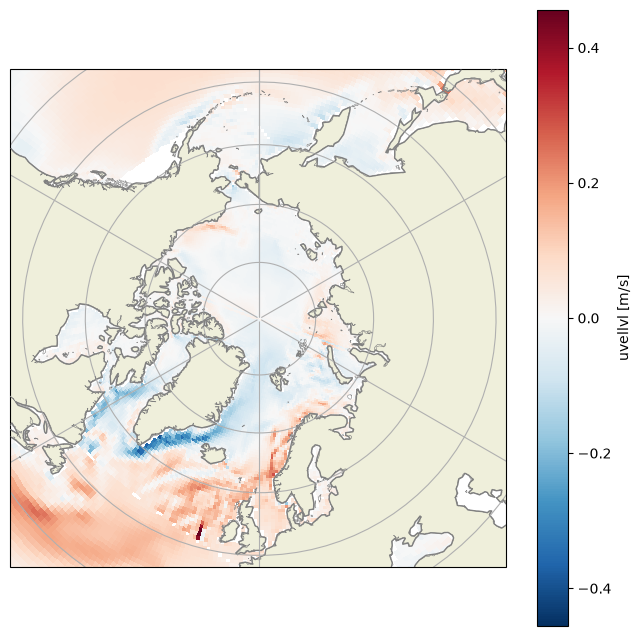

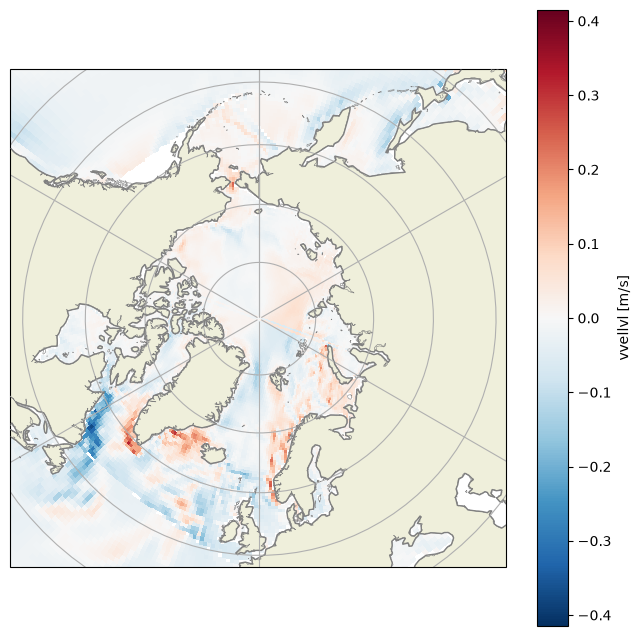

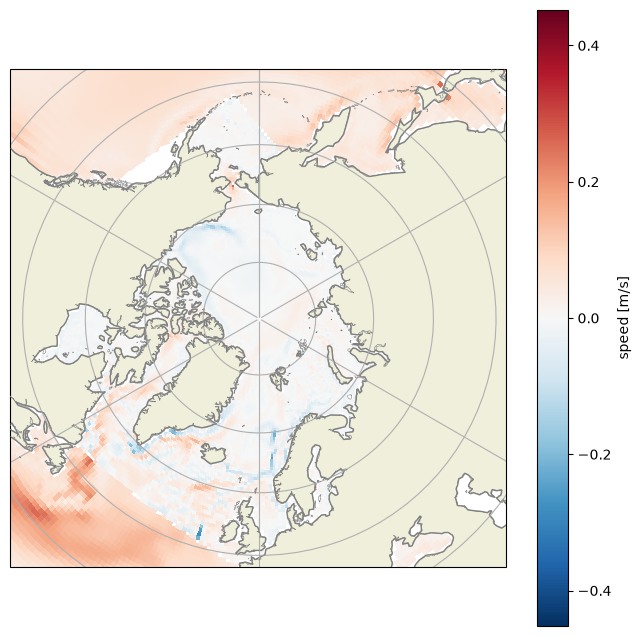

In [14]:
for (i,var) in enumerate(varlist):
    if var == "ubaro" or var == "vbaro":
        temp = ds_bias[var].mean(dim="time")
    else:
        temp = ds_bias[var].isel(depth=0).mean(dim="time")
    plt.figure(i)
    fig, ax = ArcticMap()
    vmax = np.nanmax(np.abs(temp.values))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    p = pcolormesh_curvilinear(temp.lon.values, temp.lat.values, temp.values, ax=ax, cmap="RdBu_r", norm=norm)
    fig.colorbar(p, ax=ax, label=f"{var} [m/s]")

Atlantic West   : j= 301, i=  60, grid=(55.22°, 310.03°)
Atlantic East   : j= 298, i=  89, grid=(54.00°, 339.49°)
Pacific         : j= 306, i= 291, grid=(58.17°, 182.17°)


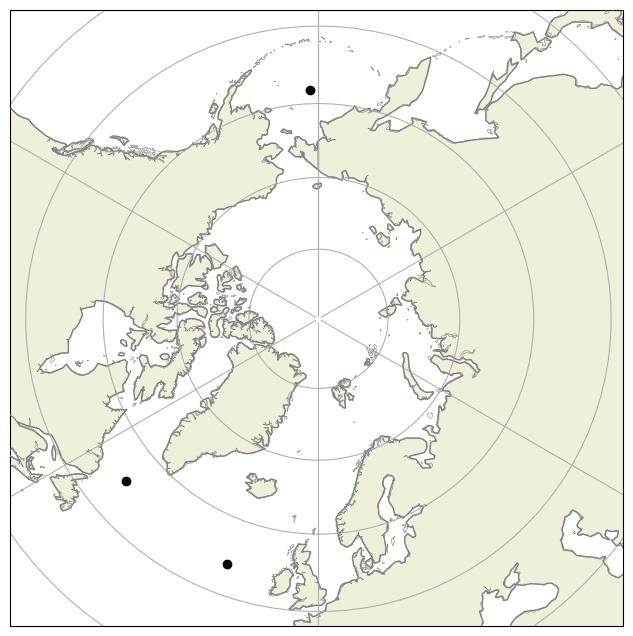

In [15]:
POINTS = {
    "Atlantic West": {"lat": 55.0, "lon": -50.0},
    "Atlantic East": {"lat": 54.0, "lon": -20.0},
    "Pacific": {"lat": 58.0, "lon": -178.0},
}

lon = ds_norcpm["lon"].values   # shape (j,i)
lat = ds_norcpm["lat"].values    # shape (j,i)

point_idx = {}
fig, ax = ArcticMap()

for name, p in POINTS.items():
    dist2 = (lon - (p["lon"]%360))**2 + (lat - p["lat"])**2
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)

    point_idx[name] = (j, i)

    print(
        f"{name:16s}: j={j:4d}, i={i:4d}, "
        f"grid=({lat[j,i]:.2f}°, {lon[j,i]:.2f}°)"
    )
    plt.plot(lon[j,i],lat[j,i],"ko",transform=ccrs.PlateCarree())

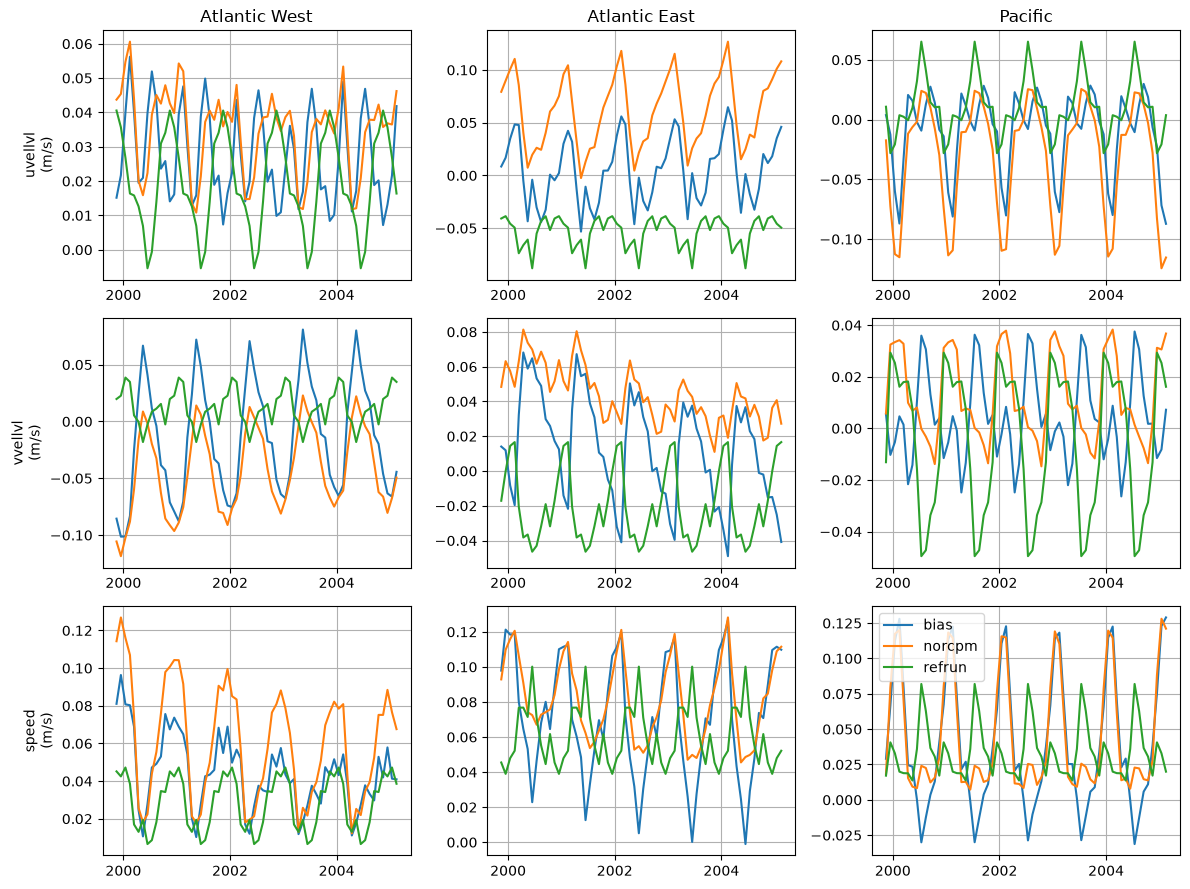

In [16]:
nrows = len(varlist)       # variables
ncols = len(point_idx)     # locations

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 3*nrows),
    squeeze=False
)

for col, (name, (y, x)) in enumerate(point_idx.items()):
    for row, var in enumerate(varlist):

        ax = axes[row, col]

        if var == "ubaro" or var == "vbaro":
            temp = ds_bias[var].isel(y=y, x=x)
            temp2 = ds_norcpm[var].isel(y=y, x=x)
            temp3 = ds_refrun_interp[var].isel(y=y, x=x)
        else:
            temp = ds_bias[var].isel(y=y, x=x, depth=0)
            temp2 = ds_norcpm[var].isel(y=y, x=x, depth=0)
            temp3 = ds_refrun_interp[var].isel(y=y, x=x, depth=0)

        temp = temp + temp2.mean()/2 + temp3.mean()/2 - temp.mean()

        temp.plot(ax=ax, label="bias")
        temp2.plot(ax=ax, label="norcpm")
        temp3.plot(ax=ax, label="refrun")

        ax.grid(True)

        # Column titles = locations
        if row == 0:
            ax.set_title(name)
        else:
            ax.set_title("")

        # Row labels = variables
        if col == 0:
            ax.set_ylabel(f"{var}\n(m/s)")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")

plt.tight_layout()
plt.legend()
plt.show()

In [17]:
for var in varlist:
    print(var)
    temp = ds_bias[var]
    #temp.to_netcdf(f"NorCPM_bias/bias_NorCPM_REFRUN_64M_{var}.nc")

uvellvl
vvellvl
speed
